In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.feature_extraction import DictVectorizer
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

%matplotlib inline

In [2]:
# Importing dataset
df = pd.read_csv('course_lead_scoring_2026.csv')
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [3]:
df.describe()

,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
count,4631.000000,5000.000000,5000.000000,4965.000000,5000.000000
mean,54533.212049,2.089400,4.472600,0.494767,0.576600
std,21245.661710,1.188987,2.435906,0.199431,0.494147
min,12000.000000,0.000000,0.000000,0.010000,0.000000
25%,40458.500000,1.000000,3.000000,0.360000,0.000000
50%,55051.000000,2.000000,4.000000,0.490000,1.000000
75%,71252.500000,3.000000,6.000000,0.630000,1.000000
max,109886.000000,6.000000,13.000000,0.990000,1.000000


In [4]:
for col in df:
    print(col, df[col].dtype)

categorial_cols = ['lead_source', 'industry', 'employment_status', 'location']
numerical_cols = ['annual_income','number_of_courses_viewed','interaction_count','lead_score']

lead_source str
industry str
employment_status str
location str
annual_income float64
number_of_courses_viewed int64
interaction_count int64
lead_score float64
converted int64


In [5]:
"""
Check if the missing values are presented in the features.
If there are missing values:

    For categorical features, replace them with 'NA'
    For numerical features, replace with with 0.0
"""
print(df.isnull().sum())
for col in df:
    if df[col].dtype == 'str':
        df[col] = df[col].fillna('NA')
    else:
        df[col] = df[col].fillna(0.0)

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64


In [6]:
print(df.isnull().sum())

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64


In [7]:
# Splitting the data
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

y_train = df_train.converted
y_val = df_val.converted
y_test = df_test.converted

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [8]:
"""
ROC AUC could also be used to evaluate feature importance of numerical variables.

Let's do that

    For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth.
    Use the training dataset for that

If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. -df_train['balance'])

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

    lead_score
    number_of_courses_viewed
    interaction_count
    annual_income
"""
print("lead_score", roc_auc_score(y_train, df_train.lead_score))
print("number_of_courses_viewed", roc_auc_score(y_train, df_train.number_of_courses_viewed))
print("interaction_count", roc_auc_score(y_train, df_train.interaction_count))
print("annual_income", roc_auc_score(y_train, df_train.annual_income))


lead_score 0.7882254810906102
number_of_courses_viewed 0.7229894623989618
interaction_count 0.7649203047563227
annual_income 0.6081977776250831


In [9]:
"""
Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

What's the AUC of this model on the validation dataset? (round to 3 digits)

    0.532
    0.632
    0.732
    0.832
"""
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorial_cols + numerical_cols].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorial_cols + numerical_cols].to_dict(orient='records')
X_val = dv.transform(val_dict)


model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]

round(roc_auc_score(y_val, y_pred),3)

0.732

/tmp/ipykernel_2200/821635519.py:32: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp/(tp+fp)


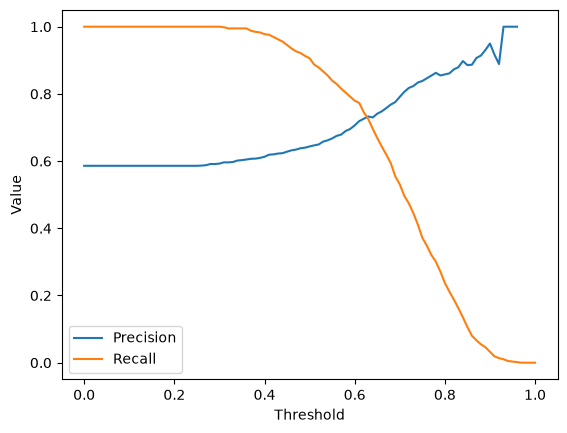

In [10]:
"""
Now let's compute precision and recall for our model.

    Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
    For each threshold, compute precision and recall
    Plot them

At which threshold precision and recall curves intersect? Ignore thresholds at which both metrics are zero, and choose the threshold with the smallest absolute difference between precision and recall.

    0.43
    0.63
    0.73
    0.83
"""
precision_vals = []
recall_vals = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    precision = tp/(tp+fp)
    recall = tp/(tp+fn)

    precision_vals.append(precision)
    recall_vals.append(recall)

precision_vals = np.array(precision_vals)
recall_vals = np.array(recall_vals)
plt.xlabel('Threshold')
plt.ylabel('Value')
plt.plot(thresholds, precision_vals, label='Precision')
plt.plot(thresholds, recall_vals, label='Recall')
plt.legend()


41


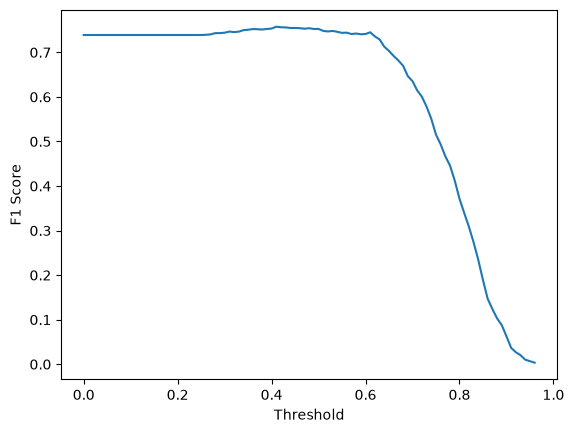

In [11]:
"""
Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

F 1 = 2 ⋅ P ⋅ R / (P + R)

Where P is precision and R is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

    0.21
    0.41
    0.61
    0.81
"""
f1_score_vals = 2*precision_vals*recall_vals/(precision_vals+recall_vals)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.plot(thresholds, f1_score_vals)

thr = np.nanargmax(f1_score_vals)
print(thr)

In [16]:
"""
Use the KFold class from Scikit-Learn to evaluate our model on 5 different folds:

KFold(n_splits=5, shuffle=True, random_state=1)

    Iterate over different folds of df_full_train
    Split the data into train and validation
    Train the model on train with these parameters: LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?

    0.001
    0.007
    0.013
    0.060
"""
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorial_cols + numerical_cols].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

def predict(df, dv, model):
    dicts = df[categorial_cols + numerical_cols].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

kfold = KFold(n_splits=5, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.732 +- 0.007


In [18]:
"""
Now let's use 5-Fold cross-validation to find the best parameter C

    Iterate over the following C values: [0.000001, 0.001, 1]
    Initialize KFold with the same parameters as previously
    Use these parameters for the model: LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    Compute the mean ROC AUC as well as the std (round the mean and std to 3 decimal digits).

Which C leads to the best mean ROC AUC?

    0.000001
    0.001
    1

If you have ties, select the score with the lowest std. If you still have ties, select the smallest C.
"""
for C in tqdm([0.000001, 0.001, 1]):

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

  0%|          | 0/3 [00:00<?, ?it/s]

C=1e-06 0.617 +- 0.019
C=0.001 0.749 +- 0.010
C=1 0.732 +- 0.007
